# Прогнозирование временных рядов (Bybit): единый Jupyter pipeline

Этот ноутбук переносит текущее решение в воспроизводимый формат:
- загрузка данных BTC/ETH с основного Bybit,
- очистка и предобработка,
- запуск моделей Naive / ARIMA,
- проверки, визуализация и экспорт результатов.

## 1) Подготовка окружения и зависимостей

Если чего-то не хватает, раскомментируй установку в ячейке ниже и перезапусти kernel.

In [90]:
# Глобальные флаги включения моделей
NAIVE_ENABLED = True
ARIMA_ENABLED = False
SARIMA_ENABLED = False
AST_ENABLED = False
NBEATS_ENABLED = True
CATBOOST_ENABLED = True
LSTM_ENABLED = True

MODEL_FLAGS = {
    'naive': NAIVE_ENABLED,
    'arima': ARIMA_ENABLED,
    'sarima': SARIMA_ENABLED,
    'ast': AST_ENABLED,
    'nbeats': NBEATS_ENABLED,
    'catboost': CATBOOST_ENABLED,
    'lstm': LSTM_ENABLED,
}

In [91]:
# При необходимости установки (раскомментируй):
# %pip install pandas numpy requests statsmodels matplotlib seaborn torch

import sys
print('Python:', sys.version)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


## 2) Импорт модулей и базовые настройки

Задаём импорты, параметры отображения и конфигурацию загрузки данных.

In [92]:
from __future__ import annotations

import importlib
import os
import pandas as pd
import seaborn as sns
from pathlib import Path

from data_pipeline import DataConfig, DataProcessor, fetch_klines, build_datasets
import model_baselines as _mb
from export_utils import plot_result, export_all_results

# В ноутбуке иногда остаётся старый кэш модуля после правок файла — принудительно обновляем
_mb = importlib.reload(_mb)
run_naive = _mb.run_naive
run_arima = _mb.run_arima
run_sarima = _mb.run_sarima
run_nbeats = _mb.run_nbeats
run_catboost = _mb.run_catboost
run_lstm = _mb.run_lstm
run_lstm_gridsearchcv_native_pipeline = _mb.run_lstm_gridsearchcv_native_pipeline
run_naive_gridsearchcv_native_pipeline = _mb.run_naive_gridsearchcv_native_pipeline
run_arima_gridsearchcv_native_pipeline = _mb.run_arima_gridsearchcv_native_pipeline
run_sarima_gridsearchcv_native_pipeline = _mb.run_sarima_gridsearchcv_native_pipeline
run_nbeats_gridsearchcv_native_pipeline = _mb.run_nbeats_gridsearchcv_native_pipeline
run_catboost_gridsearchcv_native_pipeline = _mb.run_catboost_gridsearchcv_native_pipeline

# Inference-only API: fit в модельных блоках, predict в weekly-блоке (#8.1).
fit_naive_inference_model = _mb.fit_naive_inference_model
predict_naive_inference = _mb.predict_naive_inference
fit_arima_inference_model = _mb.fit_arima_inference_model
predict_arima_inference = _mb.predict_arima_inference
fit_sarima_inference_model = _mb.fit_sarima_inference_model
predict_sarima_inference = _mb.predict_sarima_inference
fit_nbeats_inference_model = _mb.fit_nbeats_inference_model
predict_nbeats_inference = _mb.predict_nbeats_inference
fit_catboost_inference_model = _mb.fit_catboost_inference_model
predict_catboost_inference = _mb.predict_catboost_inference
fit_lstm_inference_model = _mb.fit_lstm_inference_model
predict_lstm_inference = _mb.predict_lstm_inference

CPU_COUNT = int(os.cpu_count() or 8)
SAFE_CPU_WORKERS = max(1, min(16, CPU_COUNT - 1))

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='60',
    bars=30000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)

SYMBOLS = ['BTCUSDT', 'ETHUSDT']
OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3) Загрузка входных данных/файлов

Скачиваем свечи с Bybit API и проверяем структуру.

In [93]:
raw_data = {}
LOCAL_DATA_DIR = Path('data')
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)

for symbol in SYMBOLS:
    local_file = LOCAL_DATA_DIR / f"{symbol.lower()}_timeseries.csv"
    try:
        df = fetch_klines(symbol, CONFIG)
        if df is None or len(df) == 0:
            raise RuntimeError('Bybit вернул пустой датасет')

        raw_data[symbol] = df
        df.to_csv(local_file, index=False)
        print(f"{symbol}: {len(df)} rows (скачано с API, сохранено в {local_file})")
    except Exception as e:
        if local_file.exists():
            raw_data[symbol] = pd.read_csv(local_file)
            print(f"{symbol}: API недоступен ({e}), взято локально из {local_file}, rows={len(raw_data[symbol])}")
        else:
            raise RuntimeError(
                f"{symbol}: не удалось скачать с API и нет локального файла {local_file}. Ошибка API: {e}"
            )

raw_data['BTCUSDT'].head()

BTCUSDT: 30000 rows (скачано с API, сохранено в data\btcusdt_timeseries.csv)
ETHUSDT: 30000 rows (скачано с API, сохранено в data\ethusdt_timeseries.csv)


,timestamp,open,high,low,close,volume,turnover
0,2022-10-06 04:00:00+00:00,20342.5,20435.0,20308.0,20344.0,6137.230,1.250562e+08
1,2022-10-06 05:00:00+00:00,20344.0,20360.5,20241.0,20292.5,7839.766,1.591436e+08
2,2022-10-06 06:00:00+00:00,20292.5,20292.5,20156.5,20167.5,8319.582,1.682303e+08
3,2022-10-06 07:00:00+00:00,20167.5,20240.0,20139.0,20217.0,5637.972,1.138470e+08
4,2022-10-06 08:00:00+00:00,20217.0,20244.5,20100.0,20137.0,8168.341,1.645964e+08


## 4) Очистка и предобработка данных

Убираем некорректные значения, нули и экстремальные выбросы по лог-доходности.

In [94]:
processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)
cleaned_data = {}
reports = {}

for symbol, df in raw_data.items():
    clean_df, rep = processor.process(df)
    cleaned_data[symbol] = clean_df
    reports[symbol] = rep
    print(
        f"{symbol}: before={rep['initial_rows']} after={rep['final_rows']} removed={rep['removed_total']} "
        f"(zero/nonpos={rep['removed_nonpositive_or_zero']}, outliers={rep['removed_outliers']})"
    )

cleaned_data['BTCUSDT'].head()

BTCUSDT: before=30000 after=29839 removed=161 (zero/nonpos=0, outliers=161)
ETHUSDT: before=30000 after=29851 removed=149 (zero/nonpos=0, outliers=149)


,timestamp,open,high,low,close,volume,turnover
0,2022-10-06 04:00:00+00:00,20342.5,20435.0,20308.0,20344.0,6137.230,1.250562e+08
1,2022-10-06 05:00:00+00:00,20344.0,20360.5,20241.0,20292.5,7839.766,1.591436e+08
2,2022-10-06 06:00:00+00:00,20292.5,20292.5,20156.5,20167.5,8319.582,1.682303e+08
3,2022-10-06 07:00:00+00:00,20167.5,20240.0,20139.0,20217.0,5637.972,1.138470e+08
4,2022-10-06 08:00:00+00:00,20217.0,20244.5,20100.0,20137.0,8168.341,1.645964e+08


## 5) Основная логика (функции и вычисления)

Разбиваем данные на train/test и реализуем запуск моделей.

In [95]:
datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)
for symbol, data in datasets.items():
    print(f"{symbol}: full={len(data['full'])} train={len(data['train'])} test={len(data['test'])}")

BTCUSDT: full=29839 train=23871 test=5968
ETHUSDT: full=29851 train=23880 test=5971


## 6) Проверка результата и отладочные проверки

Быстрые assert-проверки целостности данных и базового запуска.

In [96]:
for symbol in SYMBOLS:
    assert symbol in datasets, f'{symbol} отсутствует в datasets'
    assert len(datasets[symbol]['train']) > 10, f'{symbol}: слишком мало train данных'
    assert len(datasets[symbol]['test']) > 10, f'{symbol}: слишком мало test данных'
    assert (datasets[symbol]['full'] > 0).all(), f'{symbol}: есть неположительные значения после очистки'

print('Базовые проверки данных пройдены.')

# smoke-test на Naive
smoke_symbol = 'BTCUSDT'
smoke_metrics, smoke_pred = run_naive(datasets[smoke_symbol]['train'], datasets[smoke_symbol]['test'])
print('Smoke Naive metrics:', smoke_metrics)
smoke_pred.head()

Базовые проверки данных пройдены.
Smoke Naive metrics: {'MAE': 288.77556970509374, 'RMSE': 433.3764107425202, 'MAPE': 0.30158059700642226}


,y_true,y_pred
0,108100.0,107718.0
1,108712.4,108100.0
2,109385.4,108712.4
3,109104.5,109385.4
4,109493.0,109104.5


## 7) Визуализация результатов

Строим график исходного ряда и сравнение факта/прогноза для выбранной модели.

In [97]:
# 1) Начальные данные
RUN_SYMBOL = 'BTCUSDT'  # BTCUSDT или ETHUSDT
ARIMA_ORDER = (1, 1, 1)
SARIMA_ORDER = (1, 1, 0)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 24)

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

ALL_RESULTS = {}
TRAINED_MODELS = {}

print(f'Готово к запуску моделей для {RUN_SYMBOL}')
print('Активные модели:', [m for m, enabled in MODEL_FLAGS.items() if enabled])

Готово к запуску моделей для BTCUSDT
Активные модели: ['naive', 'nbeats', 'catboost', 'lstm']


NAIVE HalvingGridSearchCV: train_points=23871 | test_points=5968 | n_splits=16


NAIVE HalvingGridSearchCV:   0%|          | 0/16 [00:00<?, ?fit/s]

n_iterations: 1
n_required_iterations: 1
n_possible_iterations: 6
min_resources_: 40
max_resources_: 23871
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 1
n_resources: 40
Fitting 16 folds for each of 1 candidates, totalling 16 fits


NAIVE HalvingGridSearchCV: 100%|██████████| 16/16 [00:05<00:00,  2.69fit/s]

NAIVE split info: {'full_points': 29839, 'train_points': 23871, 'test_points': 5968, 'test_ratio': 0.2, 'cv_n_splits': 16}
NAIVE best params: {'strategy': 'last', 'resource_points': 40}


,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_strategy,param_resource_points,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,split10_test_score,split11_test_score,split12_test_score,split13_test_score,split14_test_score,split15_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0,40,0.000438,0.000088,0.005789,0.000297,last,40,"{'strategy': 'last', 'resource_points': 40}",-43.149573,-89.077493,-74.241667,-68.102849,-50.745442,-86.023077,-140.009972,-206.964316,-265.154416,-186.784972,-242.190456,-196.231054,-379.934046,-389.047721,-293.533689,-273.845726,-186.564779,110.305196,1,186.564779,110.305196


SYMBOL=BTCUSDT | MODEL=naive
Metrics: {'MAE': 288.77556970509374, 'RMSE': 433.3764107425202, 'MAPE': 0.30158059700642226}


,y_true,y_pred
0,108100.0,107718.0
1,108712.4,108100.0
2,109385.4,108712.4
3,109104.5,109385.4
4,109493.0,109104.5


,y_true,y_pred
5963,65943.8,66204.1
5964,66331.3,65943.8
5965,66159.1,66331.3
5966,66504.1,66159.1
5967,67167.6,66504.1


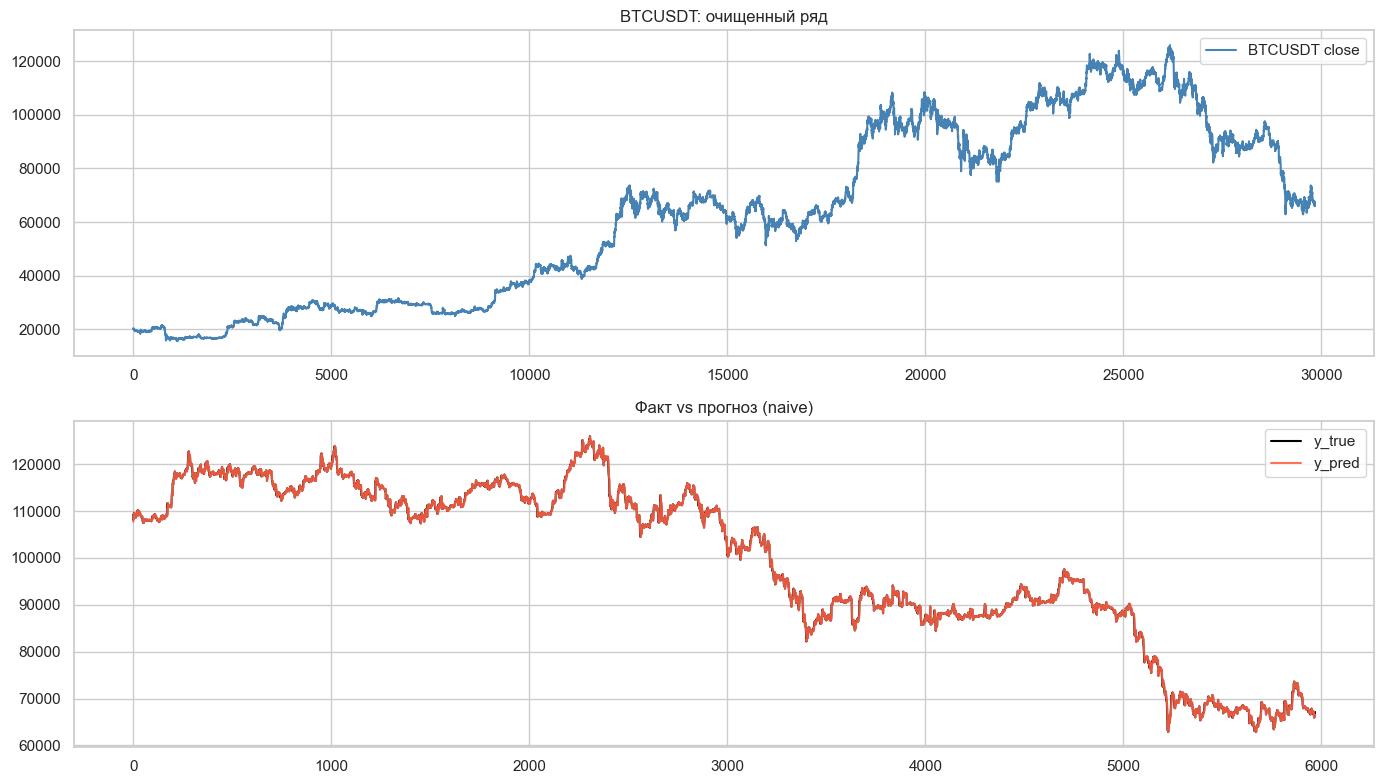

In [98]:
# 2) Модель Naive + native GridSearchCV
RUN_MODEL = 'naive'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    NAIVE_PARAM_GRID = {
        'strategy': ['last'],
    }
    NAIVE_CV_SPLITS = 16

    naive_best_params, naive_cv_df, model_metrics, pred_df, naive_split_info = run_naive_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=NAIVE_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=NAIVE_CV_SPLITS,
        scoring='MAE',
        n_jobs=SAFE_CPU_WORKERS,
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_naive_inference_model(train)

    print('NAIVE split info:', naive_split_info)
    print('NAIVE best params:', naive_best_params)
    display(naive_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

In [99]:
# 3) Модель ARIMA + native GridSearchCV
RUN_MODEL = 'arima'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    ARIMA_PARAM_GRID = {
        'p': [0, 1, 2],
        'd': [1],
        'q': [0, 1, 2],
        'refit_every': [24],
    }
    ARIMA_CV_SPLITS = 4
    ARIMA_UPDATE_STRIDE = 1

    arima_best_params, arima_cv_df, model_metrics, pred_df, arima_split_info = run_arima_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=ARIMA_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=ARIMA_CV_SPLITS,
        scoring='MAE',
        n_jobs=SAFE_CPU_WORKERS,
    )

    ARIMA_ORDER = (
        int(arima_best_params['p']),
        int(arima_best_params['d']),
        int(arima_best_params['q']),
    )
    ARIMA_HOLDOUT_REFIT_EVERY = int(arima_best_params.get('refit_every', 24))
    ARIMA_INFERENCE_REFIT_EVERY = 0

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_arima_inference_model(
        train,
        order=ARIMA_ORDER,
        update_stride=ARIMA_UPDATE_STRIDE,
        refit_every=ARIMA_INFERENCE_REFIT_EVERY,
    )

    print('ARIMA split info:', arima_split_info)
    print('ARIMA best params:', arima_best_params)
    print(
        f'ARIMA mode: update_stride={ARIMA_UPDATE_STRIDE}, '
        f'holdout_refit_every={ARIMA_HOLDOUT_REFIT_EVERY}, '
        f'inference_refit_every={ARIMA_INFERENCE_REFIT_EVERY}'
    )
    display(arima_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

SKIP: arima отключена (MODEL_FLAGS)


In [100]:
# 3.2) Модель SARIMA + native GridSearchCV
RUN_MODEL = 'sarima'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    SARIMA_PARAM_GRID = {
        'p': [1],
        'd': [1],
        'q': [0, 1],
        'sp': [1],
        'sd': [1],
        'sq': [0, 1],
        's': [24],
        'refit_every': [48],
        'fit_window': [1000],
        'maxiter': [50],
    }
    SARIMA_CV_SPLITS = 3

    sarima_best_params, sarima_cv_df, model_metrics, pred_df, sarima_split_info = run_sarima_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=SARIMA_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=SARIMA_CV_SPLITS,
        scoring='MAE',
        n_jobs=SAFE_CPU_WORKERS,
    )

    SARIMA_ORDER = (
        int(sarima_best_params['p']),
        int(sarima_best_params['d']),
        int(sarima_best_params['q']),
    )
    SARIMA_SEASONAL_ORDER = (
        int(sarima_best_params['sp']),
        int(sarima_best_params['sd']),
        int(sarima_best_params['sq']),
        int(sarima_best_params['s']),
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_sarima_inference_model(
        train, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER, maxiter=50
    )

    print('SARIMA split info:', sarima_split_info)
    print('SARIMA best params:', sarima_best_params)
    display(sarima_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

SKIP: sarima отключена (MODEL_FLAGS)


In [101]:
# 3.5) Модель AST + native GridSearchCV

from experiment_blocks import run_ast_gridsearchcv_native_pipeline



RUN_MODEL = 'ast'



if not MODEL_FLAGS.get(RUN_MODEL, True):

    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')

else:

    # Подстраиваем сетку под текущую длину ряда, чтобы не падать на коротких сериях

    train_points_est = int(len(full) * (1.0 - CONFIG.test_ratio))

    max_context_allowed = max(48, train_points_est - 40)

    candidate_context = [72, 96, 120, 168]

    ast_contexts = [c for c in candidate_context if c <= max_context_allowed]

    if not ast_contexts:

        ast_contexts = [max(48, min(72, max_context_allowed))]



    AST_USE_CUDA = False



    # Практичная сетка для AST (умеренное число комбинаций)

    AST_PARAM_GRID = {

        'context_len': ast_contexts,

        'pred_len': [1],

        'epochs': [20],

        'batch_size': [64],

        'lr': [6e-4],

        'min_lr': [1e-5],

        'lambda_adv': [0.006, 0.008],

        'd_steps': [1],

        'd_model': [96, 128],

        'n_heads': [4, 8],

        'n_layers': [2],

        'ff_dim': [192],

        'dropout': [0.10, 0.12],

        'topk': [24],

        'use_amp': [False],

        'use_gan': ['auto'],

    }

    AST_CV_SPLITS = 3 if len(full) >= 1200 else 2



    print(f'AST auto-config: len(full)={len(full)}, context_len={ast_contexts}, cv_splits={AST_CV_SPLITS}, use_cuda={AST_USE_CUDA}')



    ast_best_params, ast_cv_df, model_metrics, pred_df, ast_split_info = run_ast_gridsearchcv_native_pipeline(

        full_series=full,

        param_grid=AST_PARAM_GRID,

        test_ratio=CONFIG.test_ratio,

        n_splits=AST_CV_SPLITS,

        scoring='MAE',

        use_cuda=AST_USE_CUDA,

        n_jobs=1,

    )



    ALL_RESULTS[RUN_MODEL] = {

        'metrics': model_metrics,

        'pred_df': pred_df.copy(),

        'symbol': RUN_SYMBOL,

    }



    print('AST split info:', ast_split_info)

    print('AST best params:', ast_best_params)

    display(ast_cv_df.head(20))

    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')

    print('Metrics:', model_metrics)

    display(pred_df.head())

    display(pred_df.tail())

    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)


SKIP: ast отключена (MODEL_FLAGS)


NBEATS device: cpu
NBEATS GridSearch config: use_cuda=False, n_jobs=16
NBEATS HalvingGridSearchCV: train_points=23871 | test_points=5968 | n_splits=3


NBEATS HalvingGridSearchCV:   0%|          | 0/294 [00:00<?, ?fit/s]

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 5
min_resources_: 160
max_resources_: 23871
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 64
n_resources: 160
Fitting 3 folds for each of 64 candidates, totalling 192 fits


NBEATS HalvingGridSearchCV:  64%|██████▍   | 189/294 [00:22<00:05, 19.30fit/s] 

----------
iter: 1
n_candidates: 22
n_resources: 480
Fitting 3 folds for each of 22 candidates, totalling 66 fits


...

NBEATS HalvingGridSearchCV: best MAE=219.129126 | {'batch_size': 128, 'context_len': 120, 'epochs': 16, 'layer_size': 256, 'layers': 4, 'lr': 0.001, 'n_blocks': 3, 'resource_points': 4320}
NBEATS device: cpu
NBEATS split info: {'full_points': 29839, 'train_points': 23871, 'test_points': 5968, 'test_ratio': 0.2, 'cv_n_splits': 3}
NBEATS best params: {'batch_size': 128, 'context_len': 120, 'epochs': 16, 'layer_size': 256, 'layers': 4, 'lr': 0.001, 'n_blocks': 3, 'resource_points': 4320}


,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_context_len,param_epochs,param_layer_size,param_layers,param_lr,param_n_blocks,param_resource_points,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,3,4320,0.000267,0.000040,9.698251,0.088250,128,120,16,256,4,0.0010,3,4320,"{'batch_size': 128, 'context_len': 120, 'epoch...",-93.957890,-229.457891,-333.971599,-219.129126,98.257002,1,219.129126,98.257002
1,3,4320,0.000270,0.000034,12.622001,0.075870,128,120,24,192,4,0.0010,4,4320,"{'batch_size': 128, 'context_len': 120, 'epoch...",-96.806244,-229.978070,-340.026777,-222.270364,99.443832,2,222.270364,99.443832
2,3,4320,0.000237,0.000038,10.144146,0.122946,128,120,24,192,4,0.0010,3,4320,"{'batch_size': 128, 'context_len': 120, 'epoch...",-94.069714,-230.948184,-358.849524,-227.955807,108.116612,3,227.955807,108.116612
3,2,1440,0.000267,0.000023,7.264306,0.075939,128,120,16,256,4,0.0010,3,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-122.203884,-237.365416,-344.504445,-234.691248,90.773522,4,234.691248,90.773522
4,1,480,0.000279,0.000041,4.708389,0.096373,128,120,16,192,4,0.0010,4,480,"{'batch_size': 128, 'context_len': 120, 'epoch...",-194.074304,-233.238193,-352.887293,-260.066597,67.553504,5,260.066597,67.553504
5,1,480,0.000244,0.000043,2.797824,0.211702,128,120,24,192,3,0.0010,3,480,"{'batch_size': 128, 'context_len': 120, 'epoch...",-135.549176,-264.705479,-406.474495,-268.909717,110.644743,6,268.909717,110.644743
6,2,1440,0.000277,0.000028,8.711443,0.193223,128,120,24,192,4,0.0010,4,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-232.494323,-230.429135,-366.020487,-276.314648,63.437210,7,276.314648,63.437210
7,2,1440,0.000447,0.000098,5.634364,0.713985,128,120,24,192,4,0.0010,3,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-301.043766,-240.395823,-344.719781,-295.386457,42.777533,8,295.386457,42.777533
8,1,480,0.000516,0.000313,3.096961,0.077508,128,120,24,192,4,0.0010,3,480,"{'batch_size': 128, 'context_len': 120, 'epoch...",-148.967156,-403.561106,-339.161294,-297.229852,108.083931,9,297.229852,108.083931
9,2,1440,0.000620,0.000206,5.025917,0.172587,128,120,16,192,4,0.0010,4,1440,"{'batch_size': 128, 'context_len': 120, 'epoch...",-198.830920,-268.606056,-474.485154,-313.974043,117.018531,10,313.974043,117.018531


SYMBOL=BTCUSDT | MODEL=nbeats
Metrics: {'MAE': 334.8134603951056, 'RMSE': 467.87811978506335, 'MAPE': 0.3451153070981451}


,y_true,y_pred
0,108100.0,107517.688619
1,108712.4,107898.864114
2,109385.4,108509.862098
3,109104.5,109181.661235
4,109493.0,108901.330123


,y_true,y_pred
5963,65943.8,66114.010213
5964,66331.3,65854.231475
5965,66159.1,66241.545649
5966,66504.1,66069.584588
5967,67167.6,66414.142718


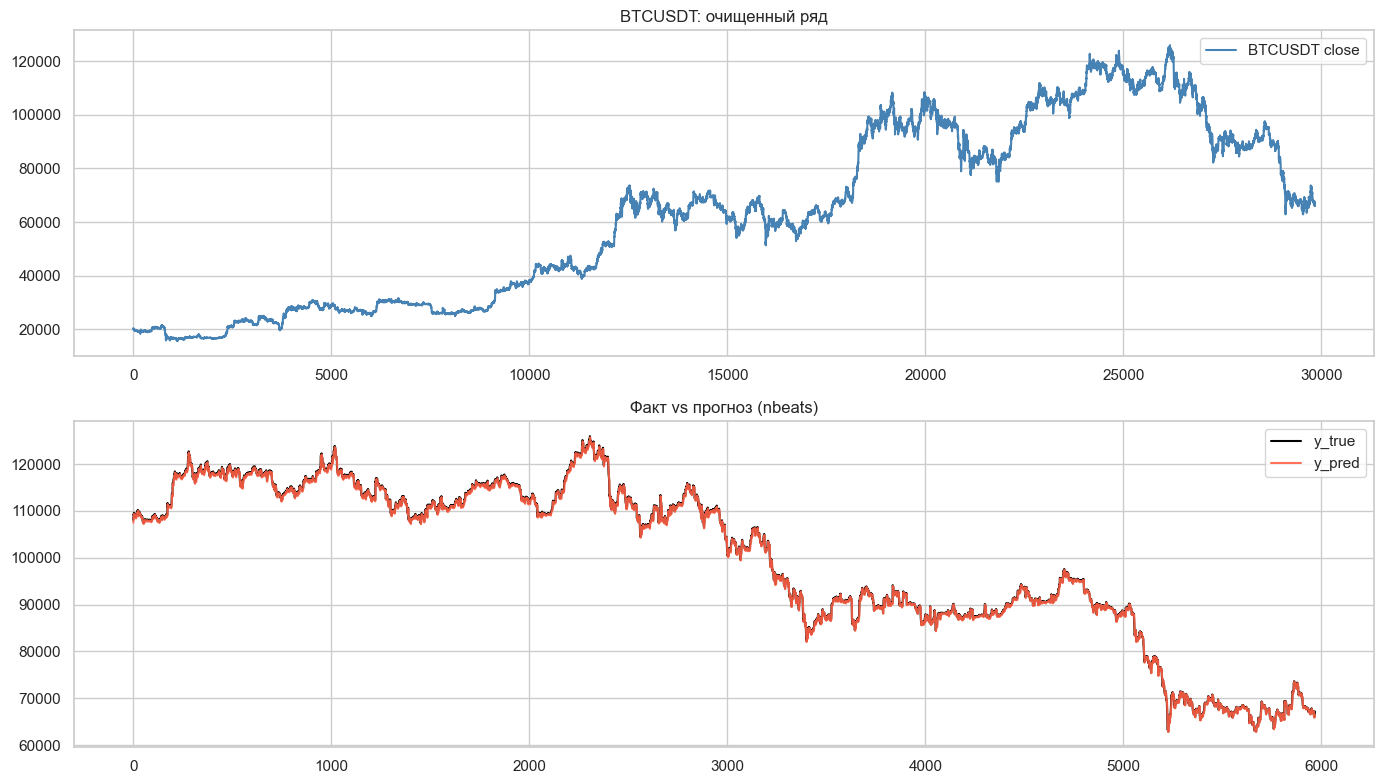

In [102]:
# 3.7) Модель N-BEATS (5-я модель) + native GridSearchCV
RUN_MODEL = 'nbeats'

if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    import torch

    NBEATS_USE_CUDA = False #torch.cuda.is_available()
    if NBEATS_USE_CUDA:
        print('NBEATS device:', torch.cuda.get_device_name(0))
    else:
        print('NBEATS device: cpu')

    NBEATS_PARAM_GRID = {
        'context_len': [120, 168],
        'n_blocks': [3, 4],
        'layers': [3, 4],
        'layer_size': [192, 256],
        'epochs': [16, 24],
        'batch_size': [128],
        'lr': [6e-4, 1e-3],
    }
    NBEATS_CV_SPLITS = 3

    nbeats_grid_jobs = 1 if NBEATS_USE_CUDA else SAFE_CPU_WORKERS
    print(f'NBEATS GridSearch config: use_cuda={NBEATS_USE_CUDA}, n_jobs={nbeats_grid_jobs}')

    nbeats_best_params, nbeats_cv_df, model_metrics, pred_df, nbeats_split_info = run_nbeats_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=NBEATS_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=NBEATS_CV_SPLITS,
        scoring='MAE',
        use_cuda=NBEATS_USE_CUDA,
        n_jobs=nbeats_grid_jobs,
    )

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_nbeats_inference_model(
        train,
        context_len=int(nbeats_best_params['context_len']),
        n_blocks=int(nbeats_best_params['n_blocks']),
        layers=int(nbeats_best_params['layers']),
        layer_size=int(nbeats_best_params['layer_size']),
        epochs=int(nbeats_best_params['epochs']),
        batch_size=int(nbeats_best_params['batch_size']),
        lr=float(nbeats_best_params['lr']),
        weight_decay=float(nbeats_best_params.get('weight_decay', 1e-4)),
        use_cuda=bool(NBEATS_USE_CUDA),
    )

    print('NBEATS split info:', nbeats_split_info)
    print('NBEATS best params:', nbeats_best_params)
    display(nbeats_cv_df.head(20))
    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())
    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

CatBoost device: NVIDIA GeForce RTX 4080
CatBoost balanced config: use_cuda=True, n_jobs=1, cv_splits=2, candidates=10
CatBoost search: min_points=512, max_points=4096, factor=4, scoring=MAE, time_weight=0.05
Balanced coverage-grid: расширенный anchor-search без полного декартова продукта.
CatBoost HalvingGridSearchCV: train_points=23871 | test_points=5968 | n_splits=2 | min_resources=512 | max_resources=4096 | factor=4 | aggressive_elimination=True | scoring=MAE


CATBOOST HalvingGridSearchCV: 100%|██████████| 26/26 [03:07<00:00,  7.21s/fit]


CatBoost HalvingGridSearchCV: best MAE=238.295490 | {'context_len': 120, 'depth': 8, 'iterations': 160, 'l2_leaf_reg': 3.0, 'learning_rate': 0.04, 'use_cuda': True}
CatBoost final fit: train_points=2048 (best halving resource window) | test_points=5968
CatBoost device: GPU
CatBoost split info: {'full_points': 29839, 'train_points': 23871, 'test_points': 5968, 'test_ratio': 0.2, 'cv_n_splits': 2, 'min_resource_points': 512, 'max_resource_points': 4096, 'best_resource_points': 2048, 'halving_factor': 4, 'aggressive_elimination': True, 'time_weight': 0.05}
CatBoost best params: {'context_len': 120, 'depth': 8, 'iterations': 160, 'l2_leaf_reg': 3.0, 'learning_rate': 0.04, 'use_cuda': True}

Топ комбинаций по HalvingGridSearchCV:


,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_context_len,param_depth,param_iterations,param_l2_leaf_reg,param_learning_rate,param_use_cuda,param_resource_points,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,1,2048,0.000197,0.000046,6.610098,0.095514,120,8,160,3.0,0.04,True,2048,"{'context_len': 120, 'depth': 8, 'iterations':...",-174.636935,-301.954045,-238.295490,63.658555,1,238.295490,63.658555
1,1,2048,0.000193,0.000036,6.665255,0.447852,120,8,280,3.0,0.03,True,2048,"{'context_len': 120, 'depth': 8, 'iterations':...",-174.650545,-302.240434,-238.445489,63.794945,2,238.445489,63.794945
2,1,2048,0.000160,0.000008,7.897578,0.012818,120,10,280,3.0,0.04,True,2048,"{'context_len': 120, 'depth': 10, 'iterations'...",-175.053290,-303.014929,-239.034110,63.980820,3,239.034110,63.980820
3,0,512,0.000230,0.000057,8.625343,0.081286,120,10,280,3.0,0.04,True,512,"{'context_len': 120, 'depth': 10, 'iterations'...",-174.556964,-304.702234,-239.629599,65.072635,4,239.629599,65.072635
4,0,512,0.000200,0.000049,7.418943,0.034840,120,8,280,3.0,0.03,True,512,"{'context_len': 120, 'depth': 8, 'iterations':...",-175.527499,-306.208221,-240.867860,65.340361,5,240.867860,65.340361
5,0,512,0.000179,0.000014,6.483226,0.012964,120,8,160,3.0,0.04,True,512,"{'context_len': 120, 'depth': 8, 'iterations':...",-175.515543,-306.319398,-240.917471,65.401928,6,240.917471,65.401928
6,0,512,0.000162,0.000005,7.181498,0.003936,120,8,280,5.0,0.04,True,512,"{'context_len': 120, 'depth': 8, 'iterations':...",-176.506859,-305.955040,-241.230950,64.724090,7,241.230950,64.724090
7,0,512,0.000223,0.000015,7.165362,0.088053,120,8,280,3.0,0.04,True,512,"{'context_len': 120, 'depth': 8, 'iterations':...",-176.233126,-307.754254,-241.993690,65.760564,8,241.993690,65.760564
8,0,512,0.000192,0.000044,7.075684,0.018107,120,8,280,3.0,0.05,True,512,"{'context_len': 120, 'depth': 8, 'iterations':...",-176.465931,-307.563892,-242.014912,65.548980,9,242.014912,65.548980
9,0,512,0.000195,0.000040,7.712226,0.091741,120,8,420,3.0,0.04,True,512,"{'context_len': 120, 'depth': 8, 'iterations':...",-176.352620,-308.348148,-242.350384,65.997764,10,242.350384,65.997764


SYMBOL=BTCUSDT | MODEL=catboost
Metrics: {'MAE': 290.8300816708903, 'RMSE': 436.2078609825381, 'MAPE': 0.3036328709640914}


,y_true,y_pred
0,108100.0,107760.751006
1,108712.4,108071.344553
2,109385.4,108714.566784
3,109104.5,109293.054167
4,109493.0,109171.691210


,y_true,y_pred
5963,65943.8,66264.241113
5964,66331.3,65955.462758
5965,66159.1,66359.039741
5966,66504.1,66129.828688
5967,67167.6,66526.428268


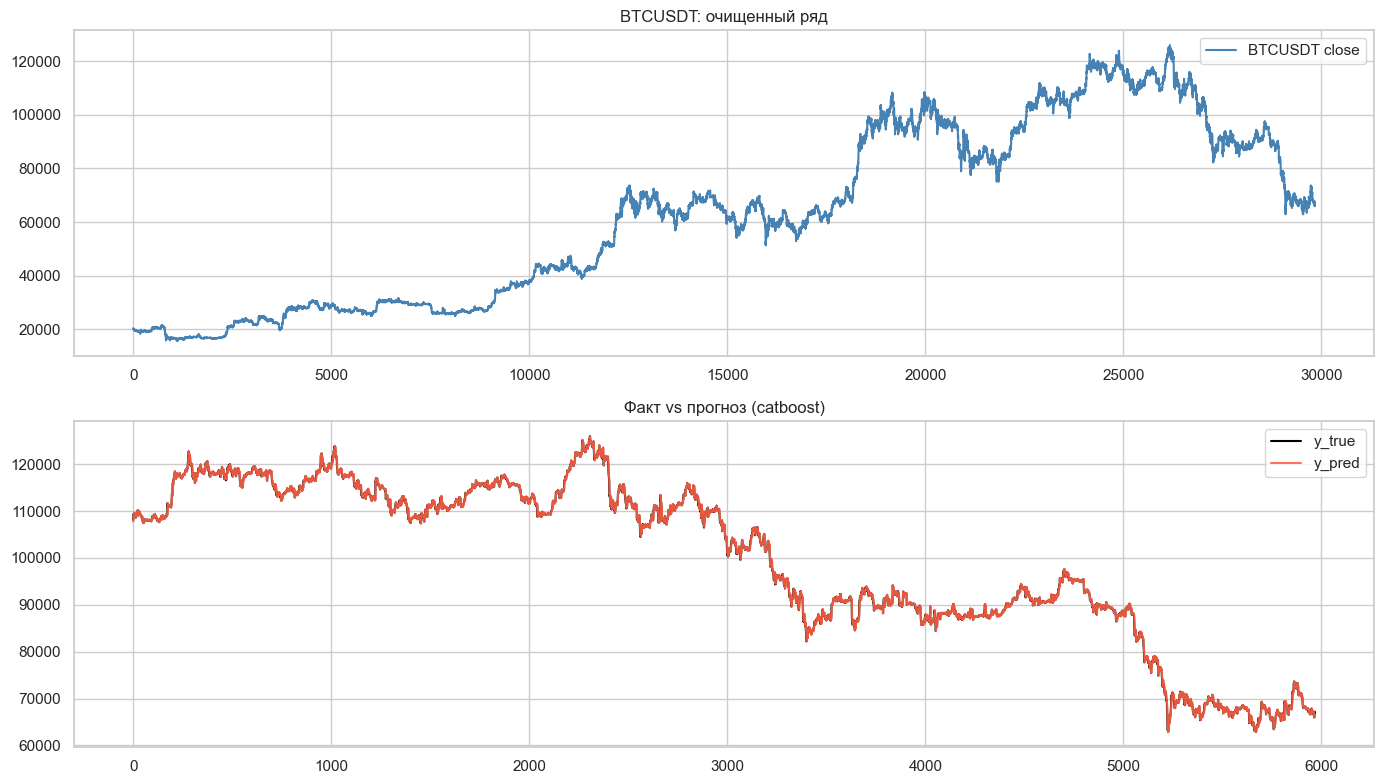

In [103]:
# 3.8) Модель CatBoost (6-я модель) + balanced native sklearn HalvingGridSearchCV
import torch
from sklearn.model_selection import ParameterGrid

RUN_MODEL = 'catboost'
if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    CATBOOST_SCORING = 'MAE'
    CATBOOST_TIME_WEIGHT = 0.05
    CATBOOST_USE_CUDA = bool(torch.cuda.is_available())
    CATBOOST_GRID_N_JOBS = 1
    CATBOOST_CV_SPLITS = 2
    CATBOOST_HALVING_FACTOR = 4
    CATBOOST_SEARCH_MIN_POINTS = 512
    CATBOOST_SEARCH_MAX_POINTS = 4_096

    def _singleton_grid(anchor):
        return {key: [value] for key, value in anchor.items()}

    def _non_anchor_values(values, anchor_value):
        return [value for value in values if value != anchor_value]

    full_values = {
        'context_len': [72, 120, 168],
        'depth': [6, 8, 10],
        'learning_rate': [0.03, 0.04, 0.05],
        'iterations': [160, 280, 420],
        'l2_leaf_reg': [3.0, 5.0],
        'use_cuda': [CATBOOST_USE_CUDA],
    }

    anchor = {
        'context_len': 120,
        'depth': 8,
        'learning_rate': 0.04,
        'iterations': 280,
        'l2_leaf_reg': 3.0,
        'use_cuda': CATBOOST_USE_CUDA,
    }

    CATBOOST_PARAM_GRID = [
        {**_singleton_grid(anchor), 'context_len': _non_anchor_values(full_values['context_len'], anchor['context_len'])},
        {**_singleton_grid(anchor), 'depth': _non_anchor_values(full_values['depth'], anchor['depth'])},
        {**_singleton_grid(anchor), 'learning_rate': _non_anchor_values(full_values['learning_rate'], anchor['learning_rate'])},
        {**_singleton_grid(anchor), 'iterations': _non_anchor_values(full_values['iterations'], anchor['iterations'])},
        {**_singleton_grid(anchor), 'l2_leaf_reg': _non_anchor_values(full_values['l2_leaf_reg'], anchor['l2_leaf_reg'])},
        _singleton_grid(anchor),
    ]

    CATBOOST_PARAM_GRID_CANDIDATES = len(ParameterGrid(CATBOOST_PARAM_GRID))

    if CATBOOST_USE_CUDA:
        print('CatBoost device:', torch.cuda.get_device_name(0))
    else:
        print('CatBoost device: cpu')
    print(
        f'CatBoost balanced config: use_cuda={CATBOOST_USE_CUDA}, n_jobs={CATBOOST_GRID_N_JOBS}, '
        f'cv_splits={CATBOOST_CV_SPLITS}, candidates={CATBOOST_PARAM_GRID_CANDIDATES}'
    )
    print(
        f'CatBoost search: min_points={CATBOOST_SEARCH_MIN_POINTS}, max_points={CATBOOST_SEARCH_MAX_POINTS}, '
        f'factor={CATBOOST_HALVING_FACTOR}, scoring={CATBOOST_SCORING}, time_weight={CATBOOST_TIME_WEIGHT}'
    )
    print('Balanced coverage-grid: расширенный anchor-search без полного декартова продукта.')

    catboost_best_params, catboost_cv_df, model_metrics, pred_df, catboost_split_info = run_catboost_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=CATBOOST_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=CATBOOST_CV_SPLITS,
        scoring=CATBOOST_SCORING,
        use_cuda=CATBOOST_USE_CUDA,
        n_jobs=CATBOOST_GRID_N_JOBS,
        min_resource_points=CATBOOST_SEARCH_MIN_POINTS,
        max_resource_points=CATBOOST_SEARCH_MAX_POINTS,
        halving_factor=CATBOOST_HALVING_FACTOR,
        aggressive_elimination=True,
        time_weight=CATBOOST_TIME_WEIGHT,
    )

    print('CatBoost split info:', catboost_split_info)
    print('CatBoost best params:', catboost_best_params)
    print('\nТоп комбинаций по HalvingGridSearchCV:')
    display(catboost_cv_df.head(20))

    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_catboost_inference_model(
        train,
        context_len=int(catboost_best_params['context_len']),
        depth=int(catboost_best_params['depth']),
        learning_rate=float(catboost_best_params['learning_rate']),
        iterations=int(catboost_best_params['iterations']),
        l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
        use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)),
    )

    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())
    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

LSTM device: NVIDIA GeForce RTX 4080
LSTM config: use_cuda=True, n_jobs=1, cv_splits=2, gpu_switch_threshold=10000, full_len=29839
LSTM search: min_points=384, max_points=4000, factor=6, aggressive_elimination=True, scoring=MAE_TIME, time_weight=0.2, candidates=13
Coverage-grid: тестируем все значения каждого гиперпараметра, но не весь декартов продукт.
LSTM HalvingGridSearchCV: train_points=23871 | test_points=5968 | n_splits=2 | min_resources=384 | max_resources=4000 | factor=6 | aggressive_elimination=True | scoring=MAE_TIME


LSTM HalvingGridSearchCV: 100%|██████████| 32/32 [03:18<00:00,  6.21s/fit]


LSTM HalvingGridSearchCV: best MAE_TIME=235.597878 | {'batch_size': 32, 'context_len': 120, 'dropout': 0.05, 'epochs': 24, 'hidden_size': 128, 'lr': 0.0006, 'num_layers': 1}
LSTM final fit: train_points=2304 (best halving resource window) | test_points=5968
LSTM split info: {'full_points': 29839, 'train_points': 23871, 'test_points': 5968, 'test_ratio': 0.2, 'cv_n_splits': 2, 'min_resources': 384, 'max_resources': 4000, 'halving_factor': 6, 'aggressive_elimination': True, 'time_weight': 0.2}
LSTM best params: {'batch_size': 32, 'context_len': 120, 'dropout': 0.05, 'epochs': 24, 'hidden_size': 128, 'lr': 0.0006, 'num_layers': 1}

Топ комбинаций по HalvingGridSearchCV:


,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_context_len,param_dropout,param_epochs,param_hidden_size,param_lr,param_num_layers,param_resource_points,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,1,2304,0.000175,0.000002,4.954912,0.125794,32,120,0.05,24,128,0.0006,1,2304,"{'batch_size': 32, 'context_len': 120, 'dropou...",-172.799194,-298.396561,-235.597878,62.798684,1,235.597878,62.798684
1,1,2304,0.000215,0.000051,7.912266,0.657174,32,120,0.10,24,128,0.0006,2,2304,"{'batch_size': 32, 'context_len': 120, 'dropou...",-172.604525,-299.018510,-235.811517,63.206992,2,235.811517,63.206992
2,1,2304,0.000186,0.000010,6.795996,0.057821,32,120,0.00,24,128,0.0006,2,2304,"{'batch_size': 32, 'context_len': 120, 'dropou...",-173.120385,-298.912341,-236.016363,62.895978,3,236.016363,62.895978
3,0,384,0.000211,0.000057,5.930019,0.005826,32,120,0.10,24,128,0.0006,2,384,"{'batch_size': 32, 'context_len': 120, 'dropou...",-173.372365,-299.182217,-236.277291,62.904926,4,236.277291,62.904926
4,0,384,0.000188,0.000021,4.062725,0.062126,32,120,0.05,24,128,0.0006,1,384,"{'batch_size': 32, 'context_len': 120, 'dropou...",-173.178467,-299.397088,-236.287778,63.109310,5,236.287778,63.109310
5,0,384,0.000169,0.000029,5.954078,0.039651,32,120,0.00,24,128,0.0006,2,384,"{'batch_size': 32, 'context_len': 120, 'dropou...",-173.375301,-299.349530,-236.362415,62.987115,6,236.362415,62.987115
6,0,384,0.000233,0.000064,5.757997,0.322079,32,120,0.05,24,128,0.0006,2,384,"{'batch_size': 32, 'context_len': 120, 'dropou...",-173.392320,-299.344646,-236.368483,62.976163,7,236.368483,62.976163
7,0,384,0.000206,0.000015,4.457999,0.259045,32,72,0.05,24,128,0.0006,2,384,"{'batch_size': 32, 'context_len': 72, 'dropout...",-173.591417,-299.170887,-236.381152,62.789735,8,236.381152,62.789735
8,0,384,0.000189,0.000037,6.997897,0.121460,32,168,0.05,24,128,0.0006,2,384,"{'batch_size': 32, 'context_len': 168, 'dropou...",-173.501322,-299.324075,-236.412699,62.911376,9,236.412699,62.911376
9,0,384,0.000172,0.000003,5.833144,0.059187,32,120,0.05,24,128,0.0010,2,384,"{'batch_size': 32, 'context_len': 120, 'dropou...",-173.544235,-299.344284,-236.444259,62.900024,10,236.444259,62.900024


SYMBOL=BTCUSDT | MODEL=lstm
Metrics: {'MAE': 289.75610344253306, 'RMSE': 436.9188719709695, 'MAPE': 0.3027552802029587}


,y_true,y_pred
0,108100.0,107731.015791
1,108712.4,108102.134687
2,109385.4,108699.636129
3,109104.5,109359.313857
4,109493.0,109064.598750


,y_true,y_pred
5963,65943.8,66248.923966
5964,66331.3,66007.443032
5965,66159.1,66359.304451
5966,66504.1,66183.755411
5967,67167.6,66507.107035


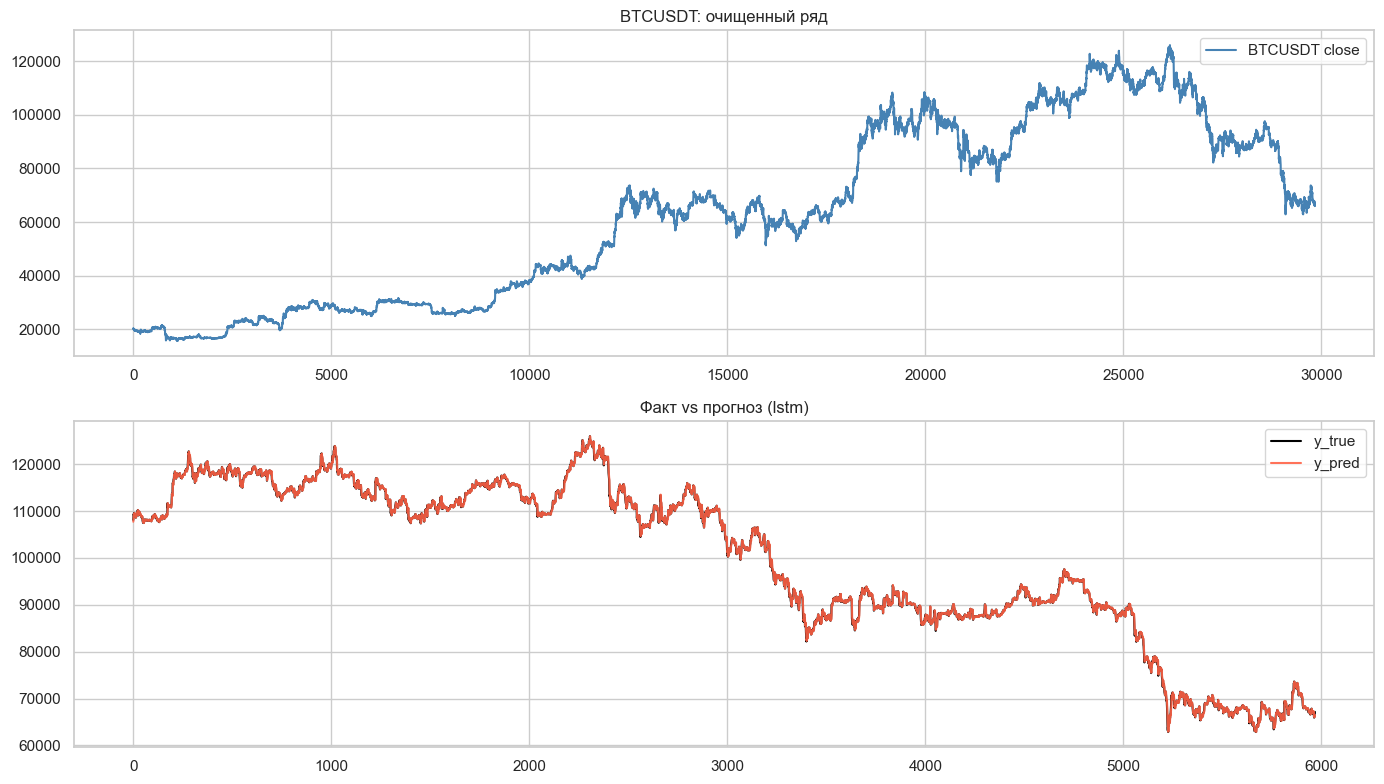

In [104]:
# 3.9) Модель LSTM (7-я модель) + native sklearn HalvingGridSearchCV
import torch
from sklearn.model_selection import ParameterGrid


RUN_MODEL = 'lstm'
if not MODEL_FLAGS.get(RUN_MODEL, True):
    print(f'SKIP: {RUN_MODEL} отключена (MODEL_FLAGS)')
else:
    LSTM_SCORING = 'MAE_TIME'
    LSTM_TIME_WEIGHT = 0.20
    LSTM_GPU_SWITCH_THRESHOLD = 10_000
    LSTM_USE_CUDA = bool(len(full) > LSTM_GPU_SWITCH_THRESHOLD and torch.cuda.is_available())
    LSTM_GRID_N_JOBS = 1 if LSTM_USE_CUDA else 16
    LSTM_CV_SPLITS = 2
    LSTM_HALVING_FACTOR = 6
    LSTM_SEARCH_MIN_POINTS = 384
    LSTM_SEARCH_MAX_POINTS = 4_000
    LSTM_AGGRESSIVE_ELIMINATION = True


    def _singleton_grid(anchor):
        return {key: [value] for key, value in anchor.items()}


    def _non_anchor_values(values, anchor_value):
        return [value for value in values if value != anchor_value]


    full_values = {
        'context_len': [72, 120, 168],
        'hidden_size': [96, 128, 160],
        'num_layers': [1, 2],
        'dropout': [0.0, 0.05, 0.10],
        'epochs': [16, 24, 32],
        'batch_size': [32, 64],
        'lr': [4e-4, 6e-4, 1e-3],
    }


    anchor = {
        'context_len': 120,
        'hidden_size': 128,
        'num_layers': 2,
        'dropout': 0.05,
        'epochs': 24,
        'batch_size': 32,
        'lr': 6e-4,
    }


    LSTM_PARAM_GRID = [
        {**_singleton_grid(anchor), 'context_len': full_values['context_len']},
        {**_singleton_grid(anchor), 'hidden_size': _non_anchor_values(full_values['hidden_size'], anchor['hidden_size'])},
        {**_singleton_grid(anchor), 'num_layers': _non_anchor_values(full_values['num_layers'], anchor['num_layers'])},
        {**_singleton_grid(anchor), 'dropout': _non_anchor_values(full_values['dropout'], anchor['dropout'])},
        {**_singleton_grid(anchor), 'epochs': _non_anchor_values(full_values['epochs'], anchor['epochs'])},
        {**_singleton_grid(anchor), 'batch_size': _non_anchor_values(full_values['batch_size'], anchor['batch_size'])},
        {**_singleton_grid(anchor), 'lr': _non_anchor_values(full_values['lr'], anchor['lr'])},
    ]


    LSTM_PARAM_GRID_CANDIDATES = len(ParameterGrid(LSTM_PARAM_GRID))


    if LSTM_USE_CUDA:
        print('LSTM device:', torch.cuda.get_device_name(0))
    else:
        print('LSTM device: cpu')
        if len(full) > LSTM_GPU_SWITCH_THRESHOLD and not torch.cuda.is_available():
            print('CUDA недоступна, поэтому LSTM оставлен на CPU.')
    print(
        f'LSTM config: use_cuda={LSTM_USE_CUDA}, n_jobs={LSTM_GRID_N_JOBS}, '
        f'cv_splits={LSTM_CV_SPLITS}, gpu_switch_threshold={LSTM_GPU_SWITCH_THRESHOLD}, full_len={len(full)}'
    )
    print(
        f'LSTM search: min_points={LSTM_SEARCH_MIN_POINTS}, max_points={LSTM_SEARCH_MAX_POINTS}, '
        f'factor={LSTM_HALVING_FACTOR}, aggressive_elimination={LSTM_AGGRESSIVE_ELIMINATION}, '
        f'scoring={LSTM_SCORING}, time_weight={LSTM_TIME_WEIGHT}, candidates={LSTM_PARAM_GRID_CANDIDATES}'
    )
    print('Coverage-grid: тестируем все значения каждого гиперпараметра, но не весь декартов продукт.')


    best_params, lstm_cv_df, model_metrics, pred_df, split_info = run_lstm_gridsearchcv_native_pipeline(
        full_series=full,
        param_grid=LSTM_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=LSTM_CV_SPLITS,
        scoring=LSTM_SCORING,
        use_cuda=LSTM_USE_CUDA,
        n_jobs=LSTM_GRID_N_JOBS,
        min_resource_points=LSTM_SEARCH_MIN_POINTS,
        max_resource_points=LSTM_SEARCH_MAX_POINTS,
        halving_factor=LSTM_HALVING_FACTOR,
        aggressive_elimination=LSTM_AGGRESSIVE_ELIMINATION,
        time_weight=LSTM_TIME_WEIGHT,
    )


    print('LSTM split info:', split_info)
    print('LSTM best params:', best_params)
    print('\nТоп комбинаций по HalvingGridSearchCV:')
    display(lstm_cv_df.head(20))


    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': RUN_SYMBOL,
    }
    TRAINED_MODELS[RUN_MODEL] = fit_lstm_inference_model(
        train,
        context_len=int(best_params['context_len']),
        hidden_size=int(best_params['hidden_size']),
        num_layers=int(best_params['num_layers']),
        dropout=float(best_params['dropout']),
        epochs=int(best_params['epochs']),
        batch_size=int(best_params['batch_size']),
        lr=float(best_params['lr']),
        weight_decay=float(best_params.get('weight_decay', 1e-4)),
        use_cuda=LSTM_USE_CUDA,
    )


    print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
    print('Metrics:', model_metrics)
    display(pred_df.head())
    display(pred_df.tail())
    plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

In [105]:
# 8.0) Bootstrap import path для локальных модулей проекта
import importlib
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    cur = start.resolve()
    markers = ('model_baselines.py', 'data_pipeline.py', 'experiment_blocks.py')
    for candidate in (cur, *cur.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    return cur

PROJECT_ROOT = _find_project_root(Path.cwd())
project_root_str = str(PROJECT_ROOT)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

import experiment_blocks as _exp
_exp = importlib.reload(_exp)

print('PROJECT_ROOT for imports:', PROJECT_ROOT)
print('experiment_blocks module:', _exp.__file__)

PROJECT_ROOT for imports: C:\Users\zzz20\ModelLine
experiment_blocks module: C:\Users\zzz20\ModelLine\experiment_blocks.py


In [106]:
# 8.1) 100 случайных недельных датасетов с Bybit: inference-only тест уже обученных моделей (многопоток)
import random
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
from tqdm import tqdm

import experiment_blocks as _exp

_exp = importlib.reload(_exp)
N_WEEKS_REQUESTED = 100
ENABLED_MODELS = [m for m, enabled in MODEL_FLAGS.items() if enabled]
WEEK_HOURS = 7 * 24
MAX_FETCH_ATTEMPTS_PER_WEEK = 20
MAX_RANDOM_YEARS_BACK = 4
WEEKLY_RANDOM_SEED = None
BASE_PARALLEL_WORKERS = max(2, min(12, SAFE_CPU_WORKERS))
PARALLEL_WORKERS = BASE_PARALLEL_WORKERS
if WEEKLY_RANDOM_SEED is not None:
    random.seed(int(WEEKLY_RANDOM_SEED))
    np.random.seed(int(WEEKLY_RANDOM_SEED))
if len(ENABLED_MODELS) == 0:
    raise RuntimeError('Все модели отключены в MODEL_FLAGS. Включи хотя бы одну модель для #8.1.')
if 'TRAINED_MODELS' not in globals() or not isinstance(TRAINED_MODELS, dict):
    raise RuntimeError('TRAINED_MODELS не найден. Сначала запусти модельные ячейки 2-3.9, чтобы обучить и сохранить модели.')
missing_trained = [m for m in ENABLED_MODELS if m not in TRAINED_MODELS and m != 'ast']
if missing_trained:
    raise RuntimeError(f'Нет обученных моделей для inference-only weekly: {missing_trained}. Перезапусти соответствующие модельные ячейки.')
if 'ast' in ENABLED_MODELS:
    print('ВНИМАНИЕ: AST в #8.1 inference-only пока не поддержан и будет пропущен.')
    ENABLED_MODELS = [m for m in ENABLED_MODELS if m != 'ast']
if len(ENABLED_MODELS) == 0:
    raise RuntimeError('После фильтрации не осталось моделей для #8.1.')
# Для ARIMA слишком большой parallelism только замедляет CPU-bound inference.
if 'arima' in ENABLED_MODELS:
    PARALLEL_WORKERS = min(PARALLEL_WORKERS, 2)
# История нужна только для autoregressive inference (NBEATS/LSTM/CatBoost), без обучения.
HISTORY_SERIES_FOR_INFERENCE = datasets[RUN_SYMBOL]['train'].astype(float).reset_index(drop=True)
if len(HISTORY_SERIES_FOR_INFERENCE) < 80:
    raise RuntimeError(f'Слишком короткая история для inference: {len(HISTORY_SERIES_FOR_INFERENCE)}')
print(f'Параллельный режим #8.1: workers={PARALLEL_WORKERS}, cpu_count={CPU_COUNT}')
if WEEKLY_RANDOM_SEED is not None:
    print(f'Weekly random seed: {WEEKLY_RANDOM_SEED}')
if 'arima' in ENABLED_MODELS and PARALLEL_WORKERS < BASE_PARALLEL_WORKERS:
    print('ARIMA включена: workers автоматически уменьшены, чтобы не тормозить inference на CPU.')

def _evaluate_week(week_idx: int):
    week_raw = pd.DataFrame()
    picked_start = None
    picked_end = None
    for attempt_idx in range(1, MAX_FETCH_ATTEMPTS_PER_WEEK + 1):
        try:
            candidate = _exp._fetch_week_by_random_end(
                base_url=CONFIG.base_url,
                symbol=RUN_SYMBOL,
                interval=CONFIG.interval,
                week_hours=WEEK_HOURS,
                max_years_back=MAX_RANDOM_YEARS_BACK,
            )
            if len(candidate) < WEEK_HOURS:
                continue
            ts_min = candidate['timestamp'].min()
            ts_max = candidate['timestamp'].max()
            if pd.isna(ts_min) or pd.isna(ts_max):
                continue
            week_raw = candidate.iloc[-WEEK_HOURS:].copy().reset_index(drop=True)
            picked_start = week_raw['timestamp'].min()
            picked_end = week_raw['timestamp'].max()
            break
        except Exception:
            if attempt_idx >= MAX_FETCH_ATTEMPTS_PER_WEEK:
                break
            continue
    if len(week_raw) < WEEK_HOURS:
        return {
            'week': week_idx + 1,
            'rows': [],
            'info': None,
            'message': f'Week {week_idx + 1}: пропуск, не удалось скачать валидный недельный датасет',
        }
    chunk_clean, _ = processor.process(week_raw)
    test_week = chunk_clean[CONFIG.target_col].astype(float).reset_index(drop=True)
    if len(test_week) < 24:
        return {
            'week': week_idx + 1,
            'rows': [],
            'info': None,
            'message': f'Week {week_idx + 1}: пропуск, недостаточно точек test={len(test_week)}',
        }
    info = {
        'week': week_idx + 1,
        'start_ts': picked_start,
        'end_ts': picked_end,
        'raw_points': int(len(week_raw)),
        'clean_points': int(len(test_week)),
    }
    rows = []
    for model_name in ENABLED_MODELS:
        t0 = time.perf_counter()
        try:
            if model_name == 'naive':
                m, _ = predict_naive_inference(TRAINED_MODELS['naive'], test_week)
            elif model_name == 'arima':
                m, _ = predict_arima_inference(TRAINED_MODELS['arima'], test_week)
            elif model_name == 'sarima':
                m, _ = predict_sarima_inference(TRAINED_MODELS['sarima'], test_week)
            elif model_name == 'nbeats':
                m, _ = predict_nbeats_inference(TRAINED_MODELS['nbeats'], HISTORY_SERIES_FOR_INFERENCE, test_week)
            elif model_name == 'catboost':
                m, _ = predict_catboost_inference(TRAINED_MODELS['catboost'], HISTORY_SERIES_FOR_INFERENCE, test_week)
            elif model_name == 'lstm':
                m, _ = predict_lstm_inference(TRAINED_MODELS['lstm'], HISTORY_SERIES_FOR_INFERENCE, test_week)
            else:
                continue
            elapsed_sec = float(time.perf_counter() - t0)
            rows.append({
                'symbol': RUN_SYMBOL,
                'week': week_idx + 1,
                'start_ts': picked_start,
                'end_ts': picked_end,
                'model': model_name,
                'n_points': int(len(test_week)),
                'MAE': float(m['MAE']),
                'RMSE': float(m['RMSE']),
                'MAPE': float(m['MAPE']),
                'duration_sec': elapsed_sec,
            })
        except Exception as ex:
            rows.append({
                'symbol': RUN_SYMBOL,
                'week': week_idx + 1,
                'start_ts': picked_start,
                'end_ts': picked_end,
                'model': model_name,
                'n_points': int(len(test_week)),
                'MAE': np.nan,
                'RMSE': np.nan,
                'MAPE': np.nan,
                'duration_sec': np.nan,
                'error': str(ex),
            })
    message = (
        f"Week {week_idx + 1}/{N_WEEKS_REQUESTED}: {picked_start} .. {picked_end} "
        f"| test={len(test_week)} | trained_models=inference_only"
    )
    return {'week': week_idx + 1, 'rows': rows, 'info': info, 'message': message}

weekly_wall_t0 = time.perf_counter()
results = []
progress = tqdm(total=N_WEEKS_REQUESTED, desc='Weekly inference', unit='week')
try:
    if PARALLEL_WORKERS > 1:
        with ThreadPoolExecutor(max_workers=PARALLEL_WORKERS) as executor:
            futures = {executor.submit(_evaluate_week, i): i for i in range(N_WEEKS_REQUESTED)}
            for future in as_completed(futures):
                results.append(future.result())
                progress.update(1)
    else:
        for i in range(N_WEEKS_REQUESTED):
            results.append(_evaluate_week(i))
            progress.update(1)
finally:
    progress.close()
weekly_wall_sec = float(time.perf_counter() - weekly_wall_t0)
weekly_rows = []
weeks_info = []
weekly_messages = []
for result in sorted(results, key=lambda item: item['week']):
    if result.get('info') is not None:
        weeks_info.append(result['info'])
    elif result.get('message'):
        weekly_messages.append(result['message'])
    weekly_rows.extend(result.get('rows', []))
weekly_metrics_df = pd.DataFrame(weekly_rows)
weeks_info_df = pd.DataFrame(weeks_info)
if len(weekly_metrics_df) == 0:
    raise RuntimeError('Не удалось собрать weekly-метрики. Проверь доступ к API и обученные модели.')
summary = (
    weekly_metrics_df.groupby('model', as_index=False)[['MAE', 'RMSE', 'MAPE']]
    .mean()
    .sort_values('MAE')
    .reset_index(drop=True)
)
weekly_ts = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')
weekly_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly{N_WEEKS_REQUESTED}_inference_metrics_{weekly_ts}.csv"
summary_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly{N_WEEKS_REQUESTED}_inference_summary_{weekly_ts}.csv"
weeks_info_path = OUTPUT_DIR / f"{RUN_SYMBOL}_weekly{N_WEEKS_REQUESTED}_inference_weeks_{weekly_ts}.csv"
weekly_metrics_df.to_csv(weekly_path, index=False)
summary.to_csv(summary_path, index=False)
weeks_info_df.to_csv(weeks_info_path, index=False)

def _weekly_with_score(df: pd.DataFrame, metric_col: str = 'MAE'):
    work = (
        df.copy()
        .sort_values(['week', metric_col, 'model'], na_position='last')
        .reset_index(drop=True)
    )
    if 'duration_sec' not in work.columns:
        work['duration_sec'] = np.nan
    work['color_tag'] = 'orange'
    work['score'] = 1
    for _, idxs in work.groupby('week', sort=True).groups.items():
        week_rows = work.loc[list(idxs)]
        valid = week_rows[week_rows[metric_col].notna()].sort_values(metric_col)
        if len(valid) == 0:
            continue
        best_metric = float(valid.iloc[0][metric_col])
        ranked_indices = list(valid.index)
        for rank_pos, ridx in enumerate(ranked_indices, start=1):
            cur_metric = float(work.loc[ridx, metric_col])
            worse_ratio = (cur_metric / best_metric) if best_metric > 1e-12 else np.inf
            if worse_ratio >= 2.0:
                work.loc[ridx, 'color_tag'] = 'red'
                work.loc[ridx, 'score'] = 0
            elif rank_pos == 1:
                work.loc[ridx, 'color_tag'] = 'green'
                work.loc[ridx, 'score'] = 3
            elif worse_ratio <= 1.10:
                work.loc[ridx, 'color_tag'] = 'yellow'
                work.loc[ridx, 'score'] = 2
            else:
                work.loc[ridx, 'color_tag'] = 'orange'
                work.loc[ridx, 'score'] = 1
        for ridx in week_rows.index:
            if pd.isna(work.loc[ridx, metric_col]):
                work.loc[ridx, 'color_tag'] = 'gray'
                work.loc[ridx, 'score'] = 0
    return work

def _weekly_style_with_dividers(scored_df: pd.DataFrame):
    row_styles = {i: '' for i in scored_df.index}
    color_map = {
        'green': 'background-color: #7CFC00; color: black',
        'yellow': 'background-color: #FFD700; color: black',
        'orange': 'background-color: #FFA500; color: black',
        'red': 'background-color: #ff6b6b; color: black',
        'gray': 'background-color: #D3D3D3; color: black',
    }
    def _append_style(base: str, extra: str) -> str:
        base = (base or '').strip()
        if not base:
            return extra
        if base.endswith(';'):
            return f"{base} {extra}"
        return f"{base}; {extra}"
    for idx, row in scored_df.iterrows():
        row_styles[idx] = _append_style(row_styles[idx], color_map.get(row['color_tag'], ''))
    for _, idxs in scored_df.groupby('week', sort=True).groups.items():
        last_idx = int(max(idxs))
        row_styles[last_idx] = _append_style(
            row_styles.get(last_idx, ''),
            'border-bottom: 3px solid #444'
        )
    return scored_df.style.apply(
        lambda row: [row_styles.get(row.name, '') for _ in row.index],
        axis=1,
    )

def _build_model_ranking(scored_df: pd.DataFrame, summary_df: pd.DataFrame):
    rank_input = scored_df.copy()
    rank_input['green_count'] = (rank_input['color_tag'] == 'green').astype(int)
    rank_input['red_count'] = (rank_input['color_tag'] == 'red').astype(int)
    rank_df = (
        rank_input.groupby('model', as_index=False)
        .agg(
            points=('score', 'sum'),
            green_count=('green_count', 'sum'),
            red_count=('red_count', 'sum'),
            avg_duration_sec=('duration_sec', 'mean'),
            total_duration_sec=('duration_sec', 'sum'),
            weeks_count=('week', 'nunique'),
        )
        .sort_values(['points', 'green_count', 'red_count', 'avg_duration_sec'], ascending=[False, False, True, True])
        .reset_index(drop=True)
    )
    summary_plus = summary_df.merge(rank_df, on='model', how='left')
    return rank_df, summary_plus

scored_weekly_df = _weekly_with_score(weekly_metrics_df, metric_col='MAE')
styled_weekly = _weekly_style_with_dividers(scored_weekly_df)
model_ranking_df, summary_with_rank_df = _build_model_ranking(scored_weekly_df, summary)
max_points = int(N_WEEKS_REQUESTED * 3)
completed_weeks = int(len(weeks_info_df))
skipped_weeks = int(N_WEEKS_REQUESTED - completed_weeks)
avg_wall_sec_per_week = float(weekly_wall_sec / max(1, completed_weeks))
print('\nСохранено:')
print(weekly_path.resolve())
print(summary_path.resolve())
print(weeks_info_path.resolve())
print('Активные модели для #8.1:', ENABLED_MODELS)
print('Режим #8.1: INFERENCE-ONLY (без обучения на weekly)')
print('History length for autoregressive inference:', len(HISTORY_SERIES_FOR_INFERENCE))
print(f'Обработано недель: {completed_weeks}/{N_WEEKS_REQUESTED}, пропущено: {skipped_weeks}')
print(f'Wall time total: {weekly_wall_sec:.2f} sec | avg per completed week: {avg_wall_sec_per_week:.2f} sec')
print('Примечание: avg_duration_sec ниже — это среднее время одной задачи модели, а не wall-clock всего блока.')
if weekly_messages:
    print('Пропуски weekly:', len(weekly_messages))
print('\nЛегенда цветов (по каждой неделе, метрика MAE):')
print('лучшая | в пределах +10% от лучшей | остальные | хуже лучшей на 100%+')
print('Границы между пятерками моделей выделены толстой линией.')
print('Баллы: red=0, orange=1, yellow=2, green=3')
print(f'Итог по {N_WEEKS_REQUESTED} неделям: 0 = очень плохо, {max_points} = очень хорошо')
print('\nВыбранные случайные недели:')
display(weeks_info_df)
print('\nWeekly-детализация (цветовая + баллы):')
display(styled_weekly)
print('\nРейтинг моделей по баллам:')
display(model_ranking_df)
print('\nСредние метрики + баллы + время выполнения:')
display(summary_with_rank_df)

Параллельный режим #8.1: workers=12, cpu_count=32


Weekly inference: 100%|██████████| 100/100 [00:24<00:00,  4.10week/s]



Сохранено:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_weekly100_inference_metrics_20260309_033353.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_weekly100_inference_summary_20260309_033353.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_weekly100_inference_weeks_20260309_033353.csv
Активные модели для #8.1: ['naive', 'nbeats', 'catboost', 'lstm']
Режим #8.1: INFERENCE-ONLY (без обучения на weekly)
History length for autoregressive inference: 23871
Обработано недель: 100/100, пропущено: 0
Wall time total: 24.38 sec | avg per completed week: 0.24 sec
Примечание: avg_duration_sec ниже — это среднее время одной задачи модели, а не wall-clock всего блока.

Легенда цветов (по каждой неделе, метрика MAE):
лучшая | в пределах +10% от лучшей | остальные | хуже лучшей на 100%+
Границы между пятерками моделей выделены толстой линией.
Баллы: red=0, orange=1, yellow=2, green=3
Итог по 100 неделям: 0 = очень плохо, 300 = очень хорошо

Выбранные случайные недели:


,week,start_ts,end_ts,raw_points,clean_points
0,1,2022-04-12 03:00:00+00:00,2022-04-19 02:00:00+00:00,168,167
1,2,2024-09-15 23:00:00+00:00,2024-09-22 22:00:00+00:00,168,168
2,3,2022-06-16 15:00:00+00:00,2022-06-23 14:00:00+00:00,168,168
3,4,2022-10-21 14:00:00+00:00,2022-10-28 13:00:00+00:00,168,165
4,5,2026-02-03 09:00:00+00:00,2026-02-10 08:00:00+00:00,168,168
...,...,...,...,...,...
95,96,2026-01-26 09:00:00+00:00,2026-02-02 08:00:00+00:00,168,168
96,97,2022-04-27 19:00:00+00:00,2022-05-04 18:00:00+00:00,168,168
97,98,2025-12-11 02:00:00+00:00,2025-12-18 01:00:00+00:00,168,164
98,99,2025-10-04 13:00:00+00:00,2025-10-11 12:00:00+00:00,168,168



Weekly-детализация (цветовая + баллы):


,symbol,week,start_ts,end_ts,model,n_points,MAE,RMSE,MAPE,duration_sec,color_tag,score
0,BTCUSDT,1,2022-04-12 03:00:00+00:00,2022-04-19 02:00:00+00:00,catboost,167,534.640252,5266.706783,1.342835,0.190831,green,3
1,BTCUSDT,1,2022-04-12 03:00:00+00:00,2022-04-19 02:00:00+00:00,naive,167,535.799401,5266.921660,1.345673,0.000255,yellow,2
2,BTCUSDT,1,2022-04-12 03:00:00+00:00,2022-04-19 02:00:00+00:00,lstm,167,540.423108,5265.287809,1.357244,0.562388,yellow,2
3,BTCUSDT,1,2022-04-12 03:00:00+00:00,2022-04-19 02:00:00+00:00,nbeats,167,542.301186,5265.706317,1.361907,1.862130,yellow,2
4,BTCUSDT,2,2024-09-15 23:00:00+00:00,2024-09-22 22:00:00+00:00,catboost,168,487.637260,3761.440025,0.815085,0.217923,green,3
5,BTCUSDT,2,2024-09-15 23:00:00+00:00,2024-09-22 22:00:00+00:00,nbeats,168,490.381957,3760.522245,0.819631,1.748307,yellow,2
6,BTCUSDT,2,2024-09-15 23:00:00+00:00,2024-09-22 22:00:00+00:00,lstm,168,491.496656,3760.421785,0.821553,0.618824,yellow,2
7,BTCUSDT,2,2024-09-15 23:00:00+00:00,2024-09-22 22:00:00+00:00,naive,168,491.664881,3762.060684,0.821691,0.000298,yellow,2
8,BTCUSDT,3,2022-06-16 15:00:00+00:00,2022-06-23 14:00:00+00:00,lstm,168,694.548262,6687.435533,3.342129,0.811372,green,3
9,BTCUSDT,3,2022-06-16 15:00:00+00:00,2022-06-23 14:00:00+00:00,naive,168,696.779762,6689.482940,3.351552,0.000260,yellow,2



Рейтинг моделей по баллам:


,model,points,green_count,red_count,avg_duration_sec,total_duration_sec,weeks_count
0,catboost,254,54,0,0.185799,18.579881,100
1,naive,227,27,0,0.000264,0.026409,100
2,lstm,212,12,0,0.506807,50.680722,100
3,nbeats,207,7,0,1.058987,105.898694,100



Средние метрики + баллы + время выполнения:


,model,MAE,RMSE,MAPE,points,green_count,red_count,avg_duration_sec,total_duration_sec,weeks_count
0,catboost,499.991083,3587.707835,1.220291,254,54,0,0.185799,18.579881,100
1,naive,501.880901,3588.624689,1.223089,227,27,0,0.000264,0.026409,100
2,nbeats,503.765595,3587.611865,1.229219,207,7,0,1.058987,105.898694,100
3,lstm,505.143639,3588.447411,1.229043,212,12,0,0.506807,50.680722,100


In [109]:
# 8.2) Rolling 24h benchmark на minute-данных: 40000 минут train + 10 окон по 24 часа
import time
from typing import Any
import requests

BENCHMARK_SYMBOL = RUN_SYMBOL
BENCHMARK_INTERVAL = '1'
BENCHMARK_TRAIN_MINUTES = 40_000
BENCHMARK_TEST_MINUTES = 24 * 60
BENCHMARK_WINDOWS = 10
BENCHMARK_FETCH_BUFFER = 4_000
BENCHMARK_END_TS = pd.Timestamp.now(tz='UTC').floor('min')
BENCHMARK_MODELS = [m for m, enabled in MODEL_FLAGS.items() if enabled and m != 'ast']
BENCHMARK_FORCE_CPU = False
BENCHMARK_NBEATS_EPOCH_CAP = 8
BENCHMARK_LSTM_EPOCH_CAP = 8

if len(BENCHMARK_MODELS) == 0:
    raise RuntimeError('Для rolling benchmark нет активных моделей. Включи хотя бы одну модель, кроме AST.')

print(
    f'Rolling benchmark: symbol={BENCHMARK_SYMBOL}, end_ts={BENCHMARK_END_TS}, '
    f'train_minutes={BENCHMARK_TRAIN_MINUTES}, test_minutes={BENCHMARK_TEST_MINUTES}, windows={BENCHMARK_WINDOWS}'
)
print('Модели:', BENCHMARK_MODELS)

def _fetch_klines_by_end(symbol: str, interval: str, bars: int, end_ts: pd.Timestamp, base_url: str) -> pd.DataFrame:
    endpoint = f"{base_url}/v5/market/kline"
    all_rows = []
    end_ms = int(pd.Timestamp(end_ts).tz_convert('UTC').timestamp() * 1000)
    while len(all_rows) < bars:
        limit = min(1000, bars - len(all_rows))
        params = {
            'category': 'linear',
            'symbol': symbol,
            'interval': interval,
            'limit': limit,
            'end': end_ms,
        }
        response = requests.get(endpoint, params=params, timeout=30)
        response.raise_for_status()
        payload = response.json()
        if payload.get('retCode') != 0:
            raise RuntimeError(f"Bybit error {symbol}: {payload}")
        batch = payload.get('result', {}).get('list', [])
        if not batch:
            break
        all_rows.extend(batch)
        end_ms = int(batch[-1][0]) - 1
        time.sleep(0.05)
    if not all_rows:
        raise RuntimeError(f'Не удалось получить minute-данные для {symbol}')
    cols = ['start_ms', 'open', 'high', 'low', 'close', 'volume', 'turnover']
    df = pd.DataFrame(all_rows, columns=cols).drop_duplicates(subset=['start_ms'])
    df['start_ms'] = pd.to_numeric(df['start_ms'], errors='coerce')
    for col in ['open', 'high', 'low', 'close', 'volume', 'turnover']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna().copy()
    df['timestamp'] = pd.to_datetime(df['start_ms'], unit='ms', utc=True)
    df = df.sort_values('timestamp').reset_index(drop=True)
    if len(df) > bars:
        df = df.iloc[-bars:].reset_index(drop=True)
    return df[['timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover']]

def _prepare_minute_backtest_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['timestamp'] = pd.to_datetime(out['timestamp'], errors='coerce', utc=True)
    out['close'] = pd.to_numeric(out['close'], errors='coerce')
    out = out.dropna(subset=['timestamp', 'close'])
    out = out[out['close'] > 0].copy()
    out = out.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)
    return out[['timestamp', 'close']]

def _fit_benchmark_model(model_name: str, train_series: pd.Series) -> dict[str, Any]:
    if model_name == 'naive':
        return fit_naive_inference_model(train_series)
    if model_name == 'arima':
        return fit_arima_inference_model(
            train_series,
            order=ARIMA_ORDER,
            update_stride=int(globals().get('ARIMA_UPDATE_STRIDE', 1)),
            refit_every=int(globals().get('ARIMA_INFERENCE_REFIT_EVERY', 0)),
        )
    if model_name == 'sarima':
        return fit_sarima_inference_model(
            train_series,
            order=SARIMA_ORDER,
            seasonal_order=SARIMA_SEASONAL_ORDER,
            maxiter=50,
        )
    if model_name == 'nbeats':
        if 'nbeats_best_params' not in globals():
            raise RuntimeError('nbeats_best_params не найдены. Сначала запусти 21-ю ячейку.')
        params = nbeats_best_params
        return fit_nbeats_inference_model(
            train_series,
            context_len=int(params['context_len']),
            n_blocks=int(params['n_blocks']),
            layers=int(params['layers']),
            layer_size=int(params['layer_size']),
            epochs=min(int(params['epochs']), BENCHMARK_NBEATS_EPOCH_CAP),
            batch_size=int(params['batch_size']),
            lr=float(params['lr']),
            weight_decay=float(params.get('weight_decay', 1e-4)),
            use_cuda=bool(params.get('use_cuda', globals().get('NBEATS_USE_CUDA', False))) and not BENCHMARK_FORCE_CPU,
        )
    if model_name == 'catboost':
        if 'catboost_best_params' not in globals():
            raise RuntimeError('catboost_best_params не найдены. Сначала запусти 22-ю ячейку.')
        params = catboost_best_params
        return fit_catboost_inference_model(
            train_series,
            context_len=int(params['context_len']),
            depth=int(params['depth']),
            learning_rate=float(params['learning_rate']),
            iterations=int(params['iterations']),
            l2_leaf_reg=float(params.get('l2_leaf_reg', 3.0)),
            use_cuda=bool(params.get('use_cuda', globals().get('CATBOOST_USE_CUDA', False))) and not BENCHMARK_FORCE_CPU,
        )
    if model_name == 'lstm':
        if 'best_params' not in globals():
            raise RuntimeError('LSTM best_params не найдены. Сначала запусти 23-ю ячейку.')
        params = best_params
        return fit_lstm_inference_model(
            train_series,
            context_len=int(params['context_len']),
            hidden_size=int(params['hidden_size']),
            num_layers=int(params['num_layers']),
            dropout=float(params['dropout']),
            epochs=min(int(params['epochs']), BENCHMARK_LSTM_EPOCH_CAP),
            batch_size=int(params['batch_size']),
            lr=float(params['lr']),
            weight_decay=float(params.get('weight_decay', 1e-4)),
            use_cuda=bool(globals().get('LSTM_USE_CUDA', False)) and not BENCHMARK_FORCE_CPU,
        )
    raise RuntimeError(f'Неизвестная модель для benchmark: {model_name}')

def _predict_benchmark_model(model_name: str, model_obj: dict[str, Any], train_series: pd.Series, test_series: pd.Series):
    if model_name == 'naive':
        return predict_naive_inference(model_obj, test_series)
    if model_name == 'arima':
        return predict_arima_inference(model_obj, test_series)
    if model_name == 'sarima':
        return predict_sarima_inference(model_obj, test_series)
    if model_name == 'nbeats':
        return predict_nbeats_inference(model_obj, train_series, test_series)
    if model_name == 'catboost':
        return predict_catboost_inference(model_obj, train_series, test_series)
    if model_name == 'lstm':
        return predict_lstm_inference(model_obj, train_series, test_series)
    raise RuntimeError(f'Неизвестная модель для benchmark: {model_name}')

total_required_points = BENCHMARK_TRAIN_MINUTES + BENCHMARK_WINDOWS * BENCHMARK_TEST_MINUTES
fetch_points = total_required_points + BENCHMARK_FETCH_BUFFER
minute_raw = _fetch_klines_by_end(
    symbol=BENCHMARK_SYMBOL,
    interval=BENCHMARK_INTERVAL,
    bars=fetch_points,
    end_ts=BENCHMARK_END_TS,
    base_url=CONFIG.base_url,
)
minute_df = _prepare_minute_backtest_df(minute_raw)
if len(minute_df) < total_required_points:
    raise RuntimeError(
        f'Недостаточно minute-данных после подготовки: {len(minute_df)} < {total_required_points}. '
        'Уменьши число окон или train_minutes.'
    )
minute_df = minute_df.iloc[-total_required_points:].reset_index(drop=True)
minute_series = minute_df['close'].astype(float).reset_index(drop=True)

print(
    f"Minute benchmark data: rows={len(minute_df)} | "
    f"from={minute_df['timestamp'].iloc[0]} | to={minute_df['timestamp'].iloc[-1]}"
)

benchmark_rows = []
benchmark_t0 = time.perf_counter()
for window_idx in tqdm(range(BENCHMARK_WINDOWS), desc='Rolling minute benchmark', unit='window'):
    offset = window_idx * BENCHMARK_TEST_MINUTES
    train_start = offset
    train_end = train_start + BENCHMARK_TRAIN_MINUTES
    test_start = train_end
    test_end = test_start + BENCHMARK_TEST_MINUTES

    train_series = minute_series.iloc[train_start:train_end].reset_index(drop=True)
    test_series = minute_series.iloc[test_start:test_end].reset_index(drop=True)
    train_start_ts = minute_df['timestamp'].iloc[train_start]
    train_end_ts = minute_df['timestamp'].iloc[train_end - 1]
    test_start_ts = minute_df['timestamp'].iloc[test_start]
    test_end_ts = minute_df['timestamp'].iloc[test_end - 1]

    for model_name in BENCHMARK_MODELS:
        fit_t0 = time.perf_counter()
        try:
            model_obj = _fit_benchmark_model(model_name, train_series)
            fit_sec = float(time.perf_counter() - fit_t0)
            pred_t0 = time.perf_counter()
            metrics_dict, pred_df = _predict_benchmark_model(model_name, model_obj, train_series, test_series)
            predict_sec = float(time.perf_counter() - pred_t0)
            benchmark_rows.append({
                'symbol': BENCHMARK_SYMBOL,
                'window': int(window_idx + 1),
                'model': model_name,
                'train_start_ts': train_start_ts,
                'train_end_ts': train_end_ts,
                'test_start_ts': test_start_ts,
                'test_end_ts': test_end_ts,
                'train_points': int(len(train_series)),
                'test_points': int(len(test_series)),
                'MAE': float(metrics_dict['MAE']),
                'RMSE': float(metrics_dict['RMSE']),
                'MAPE': float(metrics_dict['MAPE']),
                'fit_sec': fit_sec,
                'predict_sec': predict_sec,
                'total_sec': fit_sec + predict_sec,
            })
        except Exception as ex:
            benchmark_rows.append({
                'symbol': BENCHMARK_SYMBOL,
                'window': int(window_idx + 1),
                'model': model_name,
                'train_start_ts': train_start_ts,
                'train_end_ts': train_end_ts,
                'test_start_ts': test_start_ts,
                'test_end_ts': test_end_ts,
                'train_points': int(len(train_series)),
                'test_points': int(len(test_series)),
                'MAE': np.nan,
                'RMSE': np.nan,
                'MAPE': np.nan,
                'fit_sec': np.nan,
                'predict_sec': np.nan,
                'total_sec': np.nan,
                'error': str(ex),
            })

benchmark_wall_sec = float(time.perf_counter() - benchmark_t0)
rolling_benchmark_df = pd.DataFrame(benchmark_rows)
if len(rolling_benchmark_df) == 0:
    raise RuntimeError('Rolling benchmark не вернул результатов.')

rolling_valid_df = rolling_benchmark_df[rolling_benchmark_df['MAE'].notna()].copy()
if len(rolling_valid_df) == 0:
    raise RuntimeError('Все модели в rolling benchmark завершились с ошибкой.')

rolling_winners_df = (
    rolling_valid_df.sort_values(['window', 'MAE', 'total_sec', 'model'])
    .groupby('window', as_index=False)
    .first()[['window', 'model', 'MAE', 'total_sec']]
    .rename(columns={'model': 'winner_model', 'MAE': 'winner_MAE', 'total_sec': 'winner_total_sec'})
)

rolling_summary_df = (
    rolling_valid_df.groupby('model', as_index=False)
    .agg(
        windows=('window', 'nunique'),
        mean_MAE=('MAE', 'mean'),
        mean_RMSE=('RMSE', 'mean'),
        mean_MAPE=('MAPE', 'mean'),
        mean_fit_sec=('fit_sec', 'mean'),
        mean_predict_sec=('predict_sec', 'mean'),
        mean_total_sec=('total_sec', 'mean'),
    )
)
winner_counts_df = (
    rolling_winners_df.groupby('winner_model', as_index=False)
    .size()
    .rename(columns={'winner_model': 'model', 'size': 'wins'})
)
rolling_summary_df = rolling_summary_df.merge(winner_counts_df, on='model', how='left')
rolling_summary_df['wins'] = rolling_summary_df['wins'].fillna(0).astype(int)
rolling_summary_df = rolling_summary_df.sort_values(['wins', 'mean_MAE', 'mean_total_sec'], ascending=[False, True, True]).reset_index(drop=True)

rolling_ts = pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')
rolling_detail_path = OUTPUT_DIR / f"{BENCHMARK_SYMBOL}_minute40000_24h10_detail_{rolling_ts}.csv"
rolling_summary_path = OUTPUT_DIR / f"{BENCHMARK_SYMBOL}_minute40000_24h10_summary_{rolling_ts}.csv"
rolling_winners_path = OUTPUT_DIR / f"{BENCHMARK_SYMBOL}_minute40000_24h10_winners_{rolling_ts}.csv"
rolling_benchmark_df.to_csv(rolling_detail_path, index=False)
rolling_summary_df.to_csv(rolling_summary_path, index=False)
rolling_winners_df.to_csv(rolling_winners_path, index=False)

print(f'Rolling benchmark wall time: {benchmark_wall_sec:.2f} sec')
print('Сохранено:')
print(rolling_detail_path.resolve())
print(rolling_summary_path.resolve())
print(rolling_winners_path.resolve())
print('\nПобедители по каждому 24h окну:')
display(rolling_winners_df)
print('\nRolling benchmark detail:')
display(rolling_benchmark_df)
print('\nRolling benchmark summary:')
display(rolling_summary_df)

Rolling benchmark: symbol=BTCUSDT, end_ts=2026-03-09 03:48:00+00:00, train_minutes=40000, test_minutes=1440, windows=10
Модели: ['naive', 'nbeats', 'catboost', 'lstm']
Minute benchmark data: rows=54400 | from=2026-01-30 09:09:00+00:00 | to=2026-03-09 03:48:00+00:00


Rolling minute benchmark: 100%|██████████| 10/10 [06:41<00:00, 40.19s/window]

Rolling benchmark wall time: 401.92 sec
Сохранено:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_minute40000_24h10_detail_20260309_035550.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_minute40000_24h10_summary_20260309_035550.csv
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_minute40000_24h10_winners_20260309_035550.csv

Победители по каждому 24h окну:


,window,winner_model,winner_MAE,winner_total_sec
0,1,lstm,33.495040,22.626978
1,2,nbeats,45.969626,16.307469
2,3,lstm,40.282259,16.245051
3,4,lstm,45.549853,18.527659
4,5,nbeats,47.699753,18.389248
5,6,lstm,50.160053,20.204037
6,7,lstm,42.602819,18.853190
7,8,catboost,35.084207,2.276856
8,9,lstm,22.200638,19.229327
9,10,catboost,34.229710,2.379522



Rolling benchmark detail:


,symbol,window,model,train_start_ts,train_end_ts,test_start_ts,test_end_ts,train_points,test_points,MAE,RMSE,MAPE,fit_sec,predict_sec,total_sec
0,BTCUSDT,1,naive,2026-01-30 09:09:00+00:00,2026-02-27 03:48:00+00:00,2026-02-27 03:49:00+00:00,2026-02-28 03:48:00+00:00,40000,1440,33.560556,48.775152,0.050620,0.000247,0.000487,0.000734
1,BTCUSDT,1,nbeats,2026-01-30 09:09:00+00:00,2026-02-27 03:48:00+00:00,2026-02-27 03:49:00+00:00,2026-02-28 03:48:00+00:00,40000,1440,33.797853,48.958334,0.050977,17.327613,0.368209,17.695822
2,BTCUSDT,1,catboost,2026-01-30 09:09:00+00:00,2026-02-27 03:48:00+00:00,2026-02-27 03:49:00+00:00,2026-02-28 03:48:00+00:00,40000,1440,33.663338,48.907320,0.050774,1.358067,0.945123,2.303190
3,BTCUSDT,1,lstm,2026-01-30 09:09:00+00:00,2026-02-27 03:48:00+00:00,2026-02-27 03:49:00+00:00,2026-02-28 03:48:00+00:00,40000,1440,33.495040,48.723249,0.050519,21.971573,0.655405,22.626978
4,BTCUSDT,2,naive,2026-01-31 09:09:00+00:00,2026-02-28 03:48:00+00:00,2026-02-28 03:49:00+00:00,2026-03-01 03:48:00+00:00,40000,1440,45.989931,67.306714,0.070304,0.000419,0.000592,0.001011
5,BTCUSDT,2,nbeats,2026-01-31 09:09:00+00:00,2026-02-28 03:48:00+00:00,2026-02-28 03:49:00+00:00,2026-03-01 03:48:00+00:00,40000,1440,45.969626,67.302501,0.070273,15.926276,0.381194,16.307469
6,BTCUSDT,2,catboost,2026-01-31 09:09:00+00:00,2026-02-28 03:48:00+00:00,2026-02-28 03:49:00+00:00,2026-03-01 03:48:00+00:00,40000,1440,46.035042,67.507192,0.070377,1.209643,0.954818,2.164461
7,BTCUSDT,2,lstm,2026-01-31 09:09:00+00:00,2026-02-28 03:48:00+00:00,2026-02-28 03:49:00+00:00,2026-03-01 03:48:00+00:00,40000,1440,45.979182,67.508043,0.070286,16.292235,0.655829,16.948064
8,BTCUSDT,3,naive,2026-02-01 09:09:00+00:00,2026-03-01 03:48:00+00:00,2026-03-01 03:49:00+00:00,2026-03-02 03:48:00+00:00,40000,1440,40.299236,60.780470,0.060710,0.000435,0.000504,0.000939
9,BTCUSDT,3,nbeats,2026-02-01 09:09:00+00:00,2026-03-01 03:48:00+00:00,2026-03-01 03:49:00+00:00,2026-03-02 03:48:00+00:00,40000,1440,42.802958,63.121668,0.064469,16.187769,0.399148,16.586917



Rolling benchmark summary:


,model,windows,mean_MAE,mean_RMSE,mean_MAPE,mean_fit_sec,mean_predict_sec,mean_total_sec,wins
0,lstm,10,39.759500,57.068883,0.058357,19.322513,0.702960,20.025473,6
1,catboost,10,39.813223,57.069144,0.058436,1.320581,0.978875,2.299456,2
2,nbeats,10,40.163070,57.316876,0.058956,17.474970,0.389352,17.864321,2
3,naive,10,39.783479,56.986613,0.058392,0.000454,0.000560,0.001013,0


## 9) Сохранение артефактов и экспорт

Сохраняем предсказания и метрики, чтобы можно было быстро сравнивать запуски.

In [107]:
symbol_for_save = RUN_SYMBOL if 'RUN_SYMBOL' in globals() else 'UNKNOWN'

if 'ALL_RESULTS' not in globals() or len(ALL_RESULTS) == 0:
    raise RuntimeError('Нет результатов. Сначала запусти модельные ячейки naive, arima, sarima, ast, nbeats, lstm.')

# Подхватываем последний запуск модели, если она еще не в реестре
if 'RUN_MODEL' in globals() and 'model_metrics' in globals() and 'pred_df' in globals() and RUN_MODEL not in ALL_RESULTS:
    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': symbol_for_save,
    }

run_dir, metrics_path, metrics_df = export_all_results(
    output_dir=OUTPUT_DIR,
    symbol=symbol_for_save,
    full_series=full,
    all_results=ALL_RESULTS,
)

print('Сохранено:')
print(run_dir.resolve())
print(metrics_path.resolve())
print('\nСводная таблица метрик:')
display(metrics_df)

enabled_list = [m for m, enabled in MODEL_FLAGS.items() if enabled] if 'MODEL_FLAGS' in globals() else ['naive', 'arima', 'sarima', 'ast', 'nbeats', 'lstm']
missing_models = [m for m in enabled_list if m not in ALL_RESULTS]
if missing_models:
    print(f"\nНе хватает результатов включенных моделей: {missing_models}. Запусти соответствующие модельные ячейки.")

Сохранено:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260309_033353
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260309_033353\BTCUSDT_all_models_metrics.csv

Сводная таблица метрик:


,symbol,model,MAE,RMSE,MAPE
0,BTCUSDT,naive,288.775570,433.376411,0.301581
1,BTCUSDT,lstm,289.756103,436.918872,0.302755
2,BTCUSDT,nbeats,334.813460,467.878120,0.345115


In [108]:
import importlib

import model_baselines



print('module file:', model_baselines.__file__)

print('has run_sarima:', hasattr(model_baselines, 'run_sarima'))

print('symbols:', [s for s in dir(model_baselines) if s.startswith('run_')])

importlib.reload(model_baselines)

print('after reload has run_sarima:', hasattr(model_baselines, 'run_sarima'))


module file: C:\Users\zzz20\ModelLine\model_baselines.py
has run_sarima: True
symbols: ['run_arima', 'run_arima_gridsearchcv_native_pipeline', 'run_catboost', 'run_catboost_gridsearchcv_native_pipeline', 'run_lstm', 'run_lstm_chunked_cv_pipeline', 'run_lstm_chunked_cv_search', 'run_lstm_grid_search', 'run_lstm_gridsearchcv_native_pipeline', 'run_naive', 'run_naive_gridsearchcv_native_pipeline', 'run_nbeats', 'run_nbeats_gridsearchcv_native_pipeline', 'run_sarima', 'run_sarima_gridsearchcv_native_pipeline']
after reload has run_sarima: True
